# Homework Starter — Stage 03: Python Fundamentals

## Instructions
Fill in the cells below to complete your homework. Refer to lecture examples.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. NumPy Operations

In [3]:
values = np.arange(1, 11, dtype=float)
doubled = values * 2
squared = values ** 2
centered = values - values.mean()
print("values:", values)
print("doubled:", doubled)
print("squared:", squared)
print("centered mean:", centered.mean())
assert np.array_equal(doubled, np.arange(2, 21, 2, dtype=float))

values: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
doubled: [ 2.  4.  6.  8. 10. 12. 14. 16. 18. 20.]
squared: [  1.   4.   9.  16.  25.  36.  49.  64.  81. 100.]
centered mean: 0.0


## 2. Compare Loop vs Vectorization

In [4]:
import timeit

loop_input = list(range(10_000))
array_input = np.arange(10_000)
loop_seconds = min(timeit.repeat("[x * 2 for x in loop_input]", globals=globals(), repeat=3, number=200))
vector_seconds = min(timeit.repeat("array_input * 2", globals=globals(), repeat=3, number=200))
print(f"loop: {loop_seconds:.6f}s")
print(f"vectorized: {vector_seconds:.6f}s")
print(f"speed ratio (loop/vectorized): {loop_seconds / vector_seconds:.1f}x")
assert np.array_equal(np.array([x * 2 for x in loop_input]), array_input * 2)

loop: 0.028109s
vectorized: 0.000797s
speed ratio (loop/vectorized): 35.3x


## 3. Load and Inspect Dataset

In [5]:
from pathlib import Path

ROOT = Path.cwd()
csv_path = ROOT / "data" / "raw" / "starter_data.csv"
df = pd.read_csv(csv_path, parse_dates=["date"])
print("Head:")
display(df.head())
print("Info:")
df.info()
print("Describe:")
display(df.describe(include="number"))
assert df.shape == (10, 3)
assert df["date"].dtype.kind == 'M'

Head:


,category,value,date
0,A,10,2025-08-01
1,B,15,2025-08-02
2,A,12,2025-08-03
3,B,18,2025-08-04
4,C,25,2025-08-05


Info:
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   category  10 non-null     str           
 1   value     10 non-null     int64         
 2   date      10 non-null     datetime64[us]
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 382.0 bytes
Describe:


,value
count,10.000000
mean,17.600000
std,7.381659
min,10.000000
25%,12.250000
50%,14.500000
75%,23.250000
max,30.000000


## 4. Summary Statistics and Groupby

,count,mean,std,min,25%,50%,75%,max
value,10.0,17.6,7.381659,10.0,12.25,14.5,23.25,30.0


,category,observations,mean_value,total_value
0,A,4,11.500000,46
1,B,3,15.666667,47
2,C,3,27.666667,83


Saved: /Users/hansonsun/Documents/ChatGPT/FRE Bootcamp/homework/homework03/data/processed/summary.csv /Users/hansonsun/Documents/ChatGPT/FRE Bootcamp/homework/homework03/data/processed/groupby_category.csv


Saved bonus plot: /Users/hansonsun/Documents/ChatGPT/FRE Bootcamp/homework/homework03/data/processed/mean_value_by_category.png


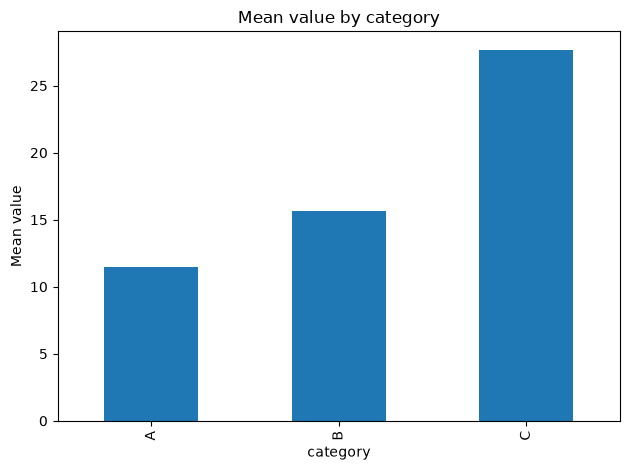

In [6]:
import sys

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.utils import get_summary_stats

summary = get_summary_stats(df)
grouped = df.groupby("category", as_index=False).agg(
    observations=("value", "size"),
    mean_value=("value", "mean"),
    total_value=("value", "sum"),
)
processed = ROOT / "data" / "processed"
processed.mkdir(parents=True, exist_ok=True)
summary_path = processed / "summary.csv"
grouped_path = processed / "groupby_category.csv"
summary.to_csv(summary_path)
grouped.to_csv(grouped_path, index=False)
display(summary)
display(grouped)
print("Saved:", summary_path, grouped_path)

ax = grouped.plot.bar(x="category", y="mean_value", legend=False, title="Mean value by category")
ax.set_ylabel("Mean value")
plot_path = processed / "mean_value_by_category.png"
ax.figure.tight_layout()
ax.figure.savefig(plot_path, dpi=120)
print("Saved bonus plot:", plot_path)

assert summary_path.is_file() and grouped_path.is_file() and plot_path.is_file()
assert grouped.set_index("category").loc["C", "mean_value"] == 27.666666666666668

## Final Checks

In [7]:
reloaded = pd.read_csv(processed / 'summary.csv', index_col=0)
assert 'value' in reloaded.index
assert int(reloaded.loc['value', 'count']) == 10
print('All Stage 03 checks passed.')

All Stage 03 checks passed.


## AI Assistance

AI assistance was used to organize and verify the notebook. Hanson Sun reviewed the calculations and outputs.